In [1]:
import numpy as np 
import bagpipes as pipes
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

from astropy.io import fits

Bagpipes: Nautilus import failed, fitting with Nautilus will be unavailable.


In [2]:
np.loadtxt('./5_band.txt')

array([[1.306530e+05, 2.607264e+01, 4.767709e+00, 1.377574e+02,
        5.819919e+00, 3.765621e+02, 7.585716e+00, 5.798005e+02,
        1.010953e+01, 7.715381e+02, 2.374905e+01],
       [2.209550e+05, 1.854550e+02, 5.707893e+00, 5.102048e+02,
        3.259338e+00, 8.309287e+02, 2.854581e+00, 1.157960e+03,
        5.519390e+00, 1.280125e+03, 1.568143e+01]])

In [3]:
np.loadtxt("./5_band.txt",
                     usecols=(0,1,3,5,7,9,
                             2,4,6,8,10))

array([[1.306530e+05, 2.607264e+01, 1.377574e+02, 3.765621e+02,
        5.798005e+02, 7.715381e+02, 4.767709e+00, 5.819919e+00,
        7.585716e+00, 1.010953e+01, 2.374905e+01],
       [2.209550e+05, 1.854550e+02, 5.102048e+02, 8.309287e+02,
        1.157960e+03, 1.280125e+03, 5.707893e+00, 3.259338e+00,
        2.854581e+00, 5.519390e+00, 1.568143e+01]])

In [11]:
def load_5_band(ID):

    # load up the relevant columns from the catalogue.
    cat = np.loadtxt("./5_band.txt",
                     usecols=(0,1,3,5,7,9,
                             2,4,6,8,10))
    ID= int(ID)
    # Find the correct row for the object we want.
    cat_ID= cat[cat[:,0]==ID][0]
    # Extract the object we want from the catalogue.
    fluxes = cat_ID[1:6]
    fluxerrs = cat_ID[6:]
    # Turn these into a 2D array.
    photometry = np.c_[fluxes, fluxerrs]
    
    return photometry

filt_list_5_band = np.loadtxt("filter_list_5_band.txt", dtype="str")

In [28]:
galaxy_5_band = pipes.galaxy("130653", load_5_band, spectrum_exists=False, filt_list=filt_list_5_band,phot_units='mujy')

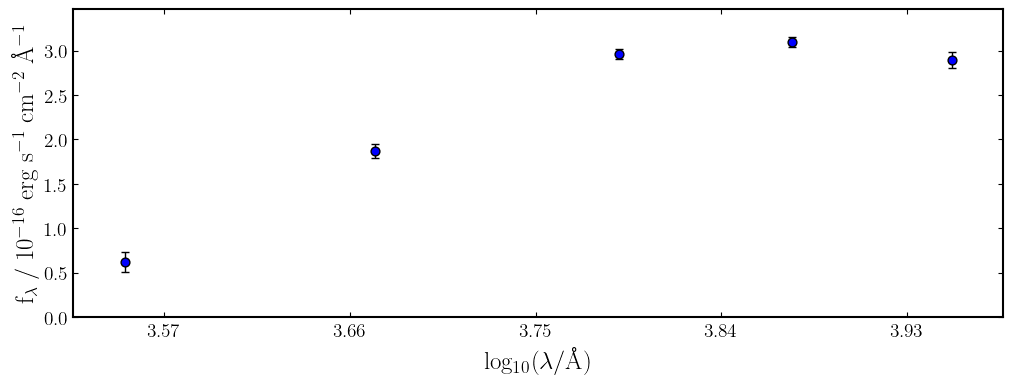

In [29]:
fig = galaxy_5_band.plot()

In [14]:
def fit_and_display(gal_id,func,filter_list,fit_info,run_name):
    temp_gal = pipes.galaxy(gal_id, fuc, spectrum_exists=False, filt_list=filter_list,phot_units='mujy')
    fit = pipes.fit(temp_gal, fit_info,run=run_name)
    fig = fit.plot_spectrum_posterior(save=False, show=True)
    fig = fit.plot_sfh_posterior(save=False, show=True)
    fig = fit.plot_corner(save=False, show=True)
    print("SFR =",np.mean(fit.posterior.samples["sfr"]),'\xB1',np.std(fit.posterior.samples["sfr"]))
    print("Stellar_mass =",np.mean(fit.posterior.samples["stellar_mass"]),'\xB1',np.std(fit.posterior.samples["stellar_mass"]))
    print("Redshift, z =",np.mean(fit.posterior.samples["redshift"]),'\xB1',np.std(fit.posterior.samples["redshift"]))    
    print("Mass weighted age =",np.mean(fit.posterior.samples["mass_weighted_age"]),'\xB1',np.std(fit.posterior.samples["mass_weighted_age"]))

In [15]:
help(pipes.galaxy.plot)

Help on function plot in module bagpipes.input.galaxy:

plot(self, show=True, return_y_scale=False, y_scale_spec=None)



In [16]:
exp = {}                                  # Tau-model star-formation history component
exp["age"] = (0.1, 15.)                   # Vary age between 100 Myr and 15 Gyr. In practice 
                                          # the code automatically limits this to the age of
                                          # the Universe at the observed redshift.

exp["tau"] = (0.3, 10.)                   # Vary tau between 300 Myr and 10 Gyr
exp["massformed"] = (1., 15.)             # vary log_10(M*/M_solar) between 1 and 15
exp["metallicity"] = (0., 2.5)            # vary Z between 0 and 2.5 Z_oldsolar


dust = {}                           
dust["type"] = "Calzetti"
dust["Av"] = (0., 2.)

nebular = {}
nebular["logU"] = (-4.,-2.)

fit_info = {}                            # The fit instructions dictionary
fit_info["redshift"] = (0., 5.)         # Vary observed redshift from 0 to 10

fit_info["exponential"] = exp
fit_info["dust"] = dust
fit_info["nebular"] = nebular


Bagpipes: fitting object 130653

 MultiNest Warning: no resume file found, starting from scratch
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    7
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.758853
Replacements:                                450
Total Samples:                               593
Nested Sampling ln(Z):            **************
Acceptance Rate:                        0.654450
Replacements:                                500
Total Samples:                               764
Nested Sampling ln(Z):            **************
Acceptance Rate:                        0.565844
Replacements:                                550
Total Samples:                               972
Nested Sampling ln(Z):            *********

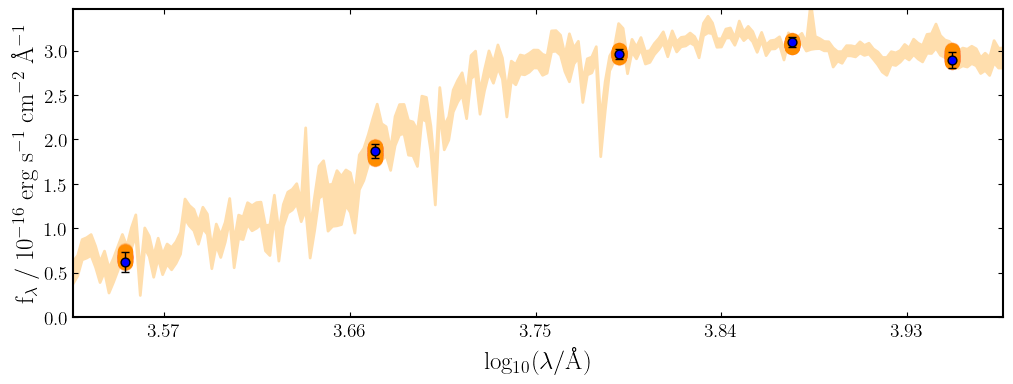

In [17]:
fit = pipes.fit(galaxy_5_band, fit_info)

fit.fit(verbose=True)

fig = fit.plot_spectrum_posterior(save=False, show=True)

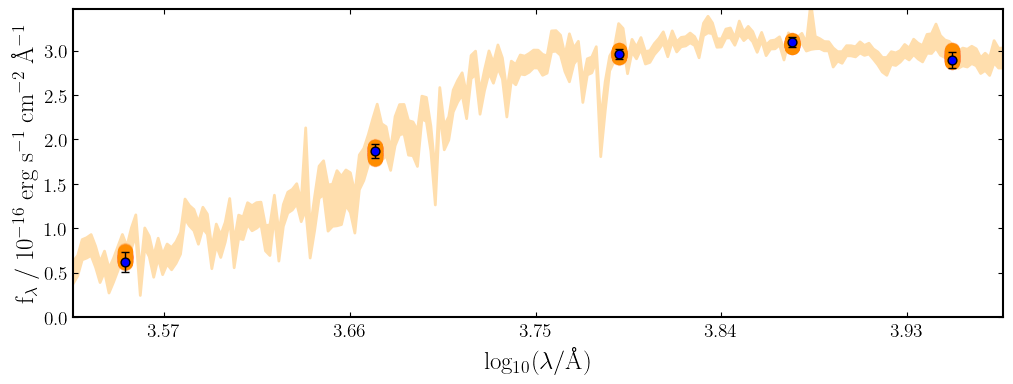

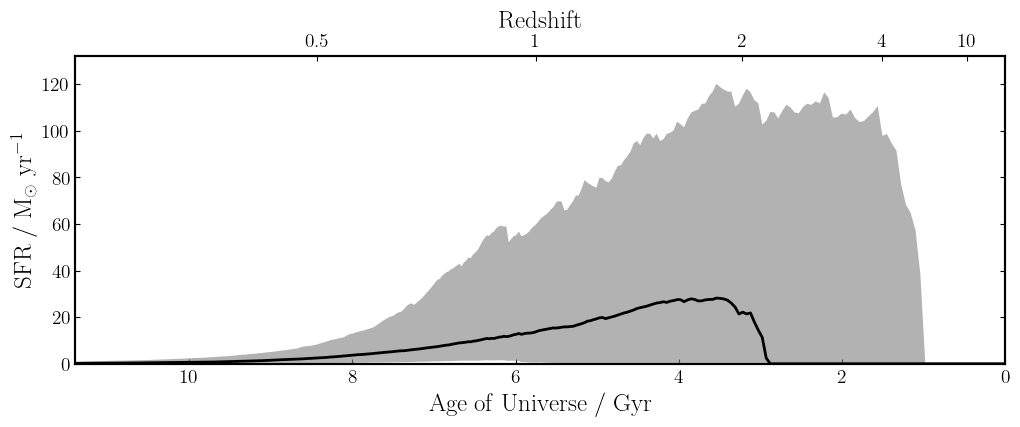

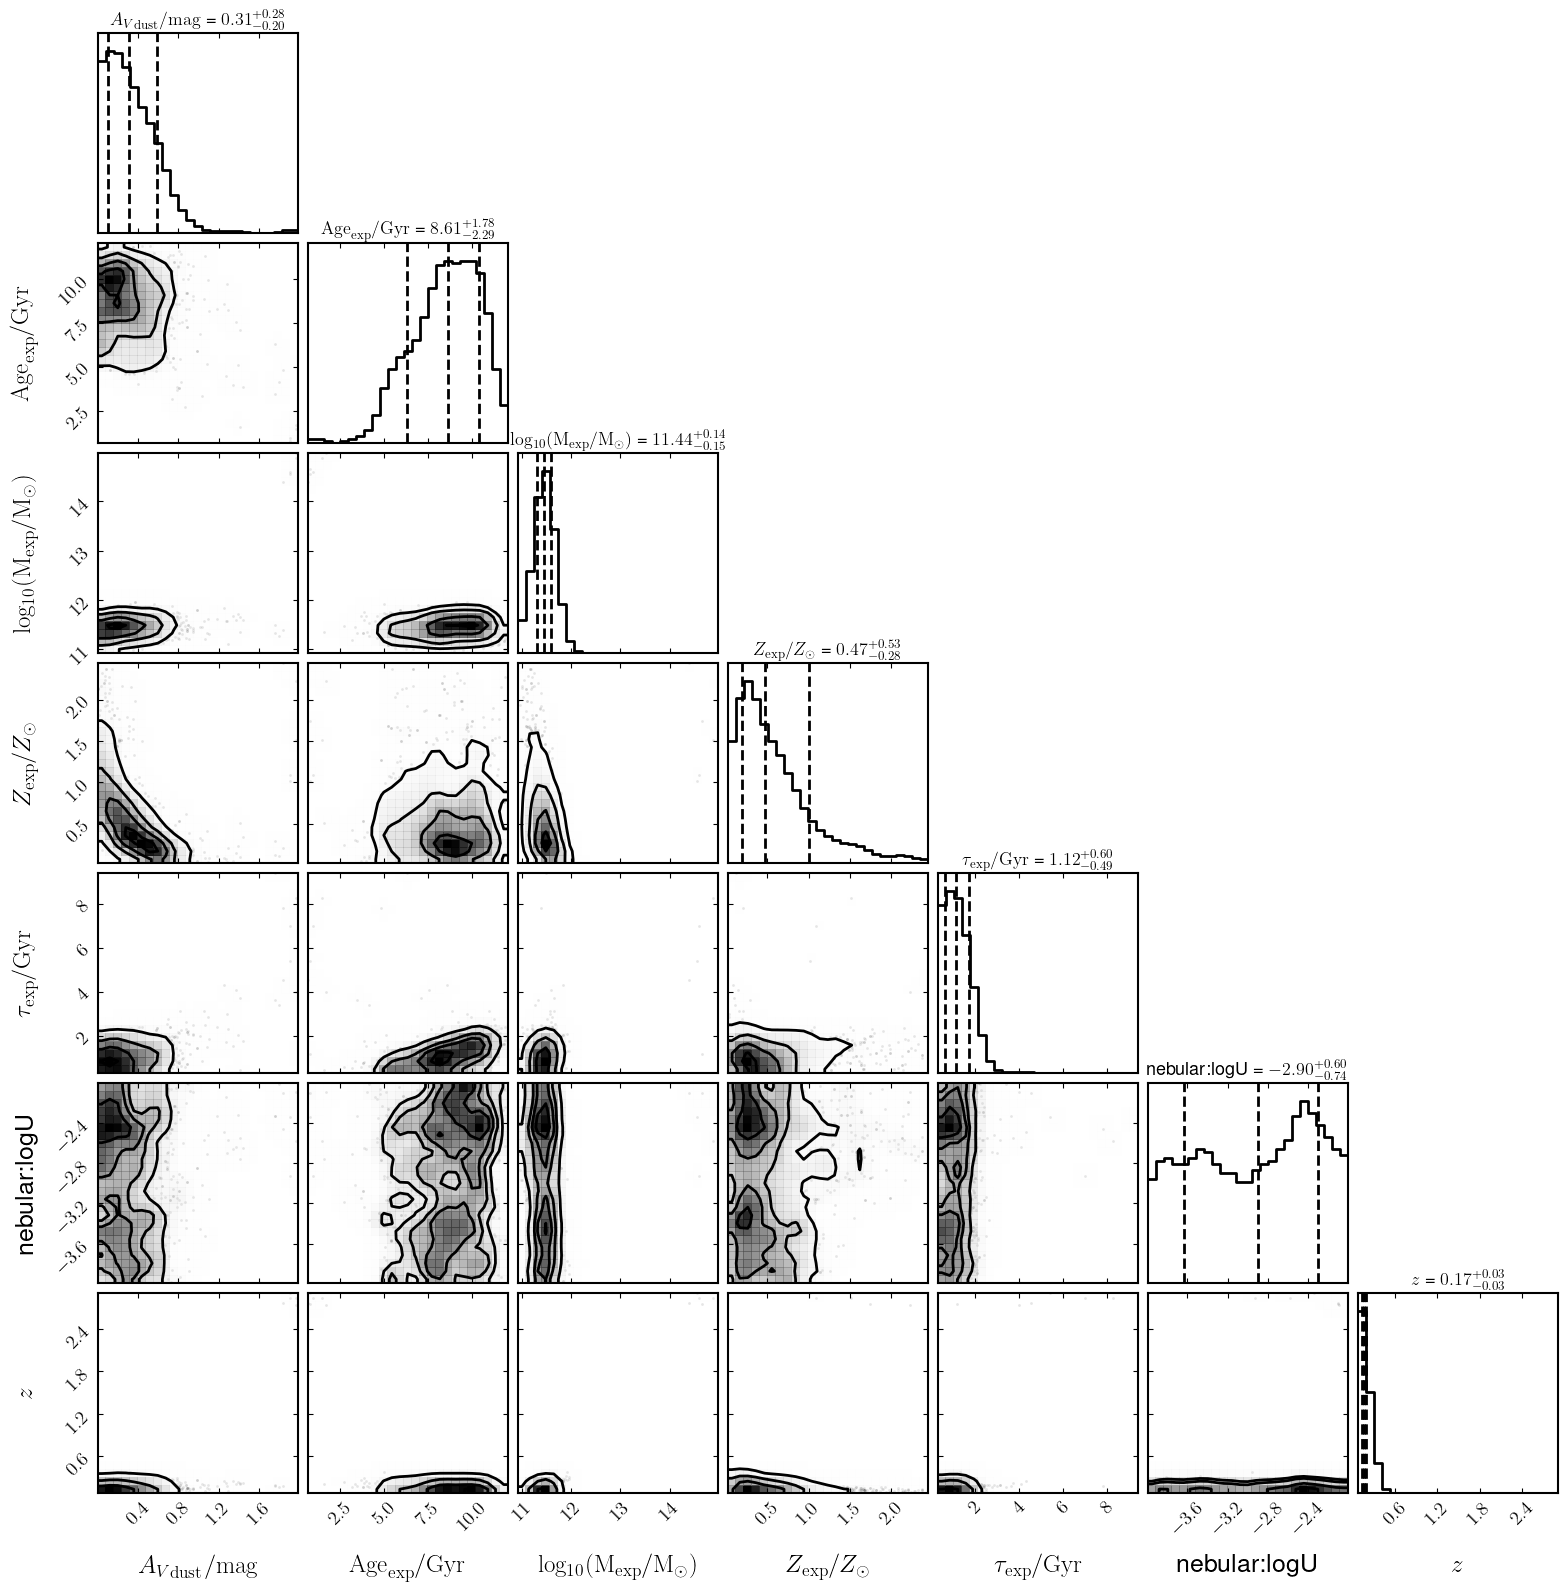

In [18]:
fig = fit.plot_spectrum_posterior(save=False, show=True)
fig = fit.plot_sfh_posterior(save=False, show=True)
fig = fit.plot_corner(save=False, show=True)

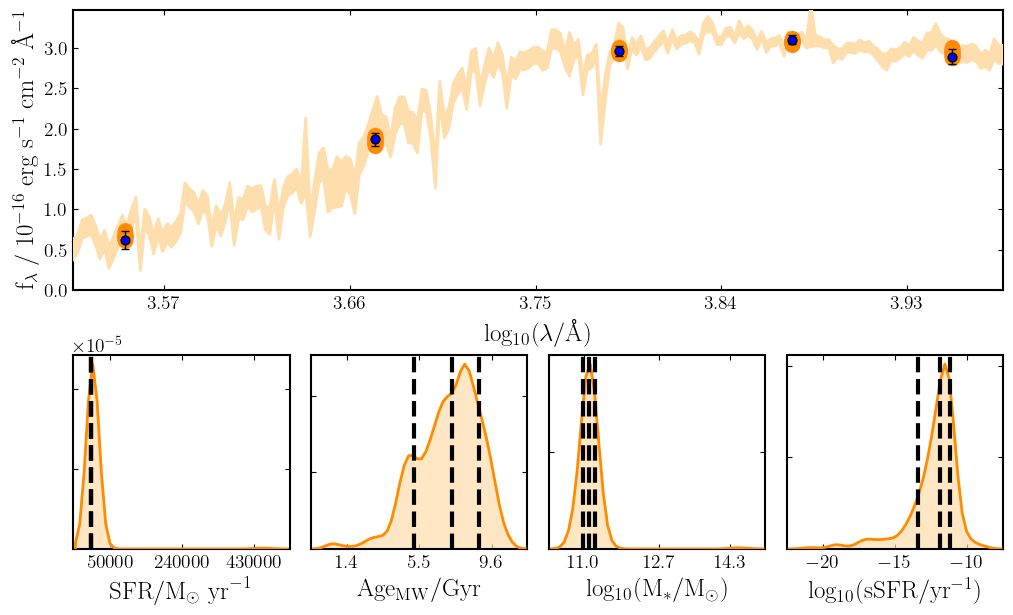

In [19]:
plt.close()

fig = plt.figure(figsize=(12, 7))
gs = mpl.gridspec.GridSpec(7, 4, hspace=3., wspace=0.1)

ax1 = plt.subplot(gs[:4, :])

pipes.plotting.add_observed_photometry(fit.galaxy, ax1, zorder=10)
pipes.plotting.add_photometry_posterior(fit, ax1)

labels = ["sfr", "mass_weighted_age", "stellar_mass", "ssfr"]

post_quantities = dict(zip(labels, [fit.posterior.samples[l] for l in labels]))

axes = []
for i in range(4):
    axes.append(plt.subplot(gs[4:, i]))
    pipes.plotting.hist1d(post_quantities[labels[i]], axes[-1], smooth=True, label=labels[i])

plt.show()

In [33]:
np.percentile(fit.posterior.samples["mass_weighted_age"], (16, 50, 84))

array([5.20961166, 7.38424951, 8.89649821])

In [41]:
def print_stats(col):
    st= np.percentile(fit.posterior.samples[col], (16, 50, 84))
    m= round(st[1],6)
    uc1= round(st[2]-st[1],6)
    uc2= round(st[1]-st[0],6)
    print(m," +",uc1," -",uc2)

def fit_and_show_results(gal_id,func,filter_list,fit_info,run_name):
    temp_gal = pipes.galaxy(gal_id, func, spectrum_exists=False, filt_list=filter_list,phot_units='mujy')
    fit = pipes.fit(temp_gal, fit_info,run=run_name)
    fit.fit(verbose=False)
    fig = fit.plot_spectrum_posterior(save=False, show=True)
    print("SFR =")
    print_stats("sfr")
    print("Stellar_mass =")
    print_stats("stellar_mass")
    print("Redshift, z =")
    print_stats("redshift")
    print("Mass weighted age =")
    print_stats("mass_weighted_age")


Results loaded from pipes/posterior//130653.h5

Fitting not performed as results have already been loaded from pipes/posterior//130653.h5. To start over delete this file or change run.



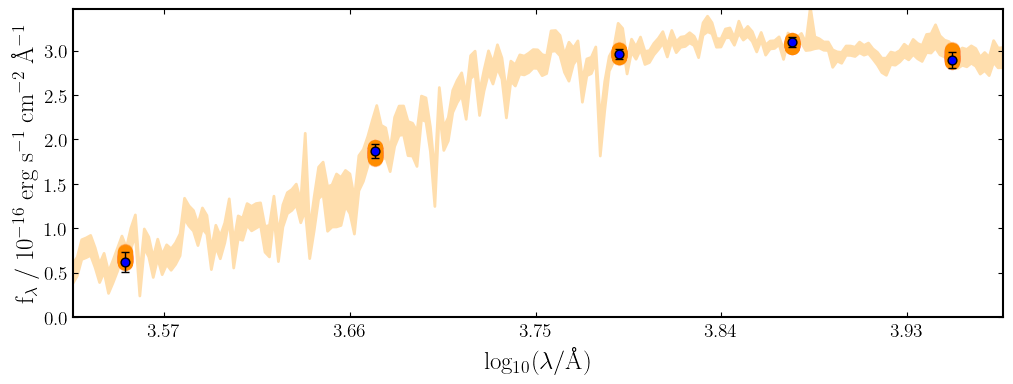

SFR =
0.176827  + 0.75868  - 0.171611
Stellar_mass =
11.112333  + 0.147275  - 0.140102
Redshift, z =
0.166922  + 0.035538  - 0.027499
Mass weighted age =
7.38425  + 1.512249  - 2.174638


In [42]:
fit_and_show_results("130653",load_5_band,filt_list_5_band,fit_info,"")